# Final Project

## Part 0 Project Proposal
Before we do the project, you will need to create a repository
1. Create the project remotely on GitHub.  You will want to include a README
2. Install GitHub Desktop.
3. From the remote repo, clone down to your local and use github desktop to create it.
4. Copy the notebook into your local repo
5. Commit and push

***Invite me and the GA to your repo***

As you make changes locally, commit and push them. 

To complete the proposal. You will record the following in your README

1. The kind of data you want to find
2. The question/s you want to answer with the data.
3. URLs for the site/s that have the data you want.

***Note: You must aquire the data via an API or Web scraping.  Downloading a file will not get points.***

All code for your project will be recorded in this note book. Create extra code cells as needed.


# Part 1: Data aquisition
    1. Get raw data and put it into files. If needed, gather a representative amount of data.  Then append additional data as available.
    


In [2]:
# Part 1: Put code here

import requests
import pandas as pd
import datetime
import time
import os

# ─────────────────────────────────────────────
# 1. Configuration
# ─────────────────────────────────────────────
SUBREDDITS   = ['fitness', 'weightlifting']
POST_LIMIT   = 500        # 100 posts per subreddit. Increase to 500+ overtime
COMMENT_LIMIT = 10     
OUTPUT_DIR   = 'data'  

HEADERS = {'User-Agent': 'python:university_research_project:v1.0 (by /u/SuspiciousKiwi3427'}

os.makedirs(OUTPUT_DIR, exist_ok=True)



In [3]:
# ─────────────────────────────────────────────
# 2. Scraping functions
# ─────────────────────────────────────────────
def get_posts(subreddit_name, limit=100):
    """Fetch top posts from a subreddit using Reddit's public JSON endpoint."""
    posts = []
    after = None 

    print(f'Scraping r/{subreddit_name}...')

    while len(posts) < limit:
        url = f'https://www.reddit.com/r/{subreddit_name}/top.json?t=year&limit=25'
        if after:
            url += f'&after={after}'

        response = requests.get(url, headers=HEADERS)

        if response.status_code != 200:
            print(f'  Request failed with status {response.status_code}. Stopping.')
            break

        data = response.json()['data']
        children = data['children']

        if not children:
            break

        for child in children:
            p = child['data']
            created = datetime.datetime.utcfromtimestamp(p['created_utc'])
            posts.append({
                'id':           p['id'],
                'subreddit':    subreddit_name,
                'title':        p['title'],
                'body':         p.get('selftext', ''),
                'score':        p['score'],
                'num_comments': p['num_comments'],
                'created_utc':  p['created_utc'],
                'created_date': created.strftime('%Y-%m-%d'),
                'month':        created.month,
                'year':         created.year,
            })

        after = data['after']  # move to next page
        if not after:
            break

        time.sleep(2)

    print(f'  Collected {len(posts)} posts.')
    return pd.DataFrame(posts[:limit])


def get_comments(post_id, subreddit_name, limit=10):
    """Fetch top-level comments for a single post."""
    url = f'https://www.reddit.com/r/{subreddit_name}/comments/{post_id}.json?limit={limit}'
    response = requests.get(url, headers=HEADERS)

    if response.status_code != 200:
        return []

    comments = []
    try:
        comment_data = response.json()[1]['data']['children']
        for c in comment_data[:limit]:
            if c['kind'] == 't1':
                comments.append({
                    'post_id':    post_id,
                    'subreddit':  subreddit_name,
                    'comment_id': c['data']['id'],
                    'body':       c['data']['body'],
                    'score':      c['data']['score'],
                    'created_utc': c['data']['created_utc'],
                })
    except Exception as e:
        print(f'  Could not parse comments for post {post_id}: {e}')

    return comments

In [5]:
# ─────────────────────────────────────────────
# 3. Run scraper for both subreddits
# ─────────────────────────────────────────────
all_posts = []
all_comments = []

for sub in SUBREDDITS:
    posts_df = get_posts(sub, limit=POST_LIMIT)
    all_posts.append(posts_df)

    print(f'  Fetching comments for r/{sub}...')
    for post_id in posts_df['id']:
        comments = get_comments(post_id, sub, limit=COMMENT_LIMIT)
        all_comments.extend(comments)
        time.sleep(1)  # pause between comment requests

    print(f'  Done with r/{sub}.')

if all_posts:
    posts_combined    = pd.concat(all_posts, ignore_index=True)
    comments_combined = pd.DataFrame(all_comments)

    # CSV
    posts_combined.to_csv(f'{OUTPUT_DIR}/raw_posts.csv', index=False)
    comments_combined.to_csv(f'{OUTPUT_DIR}/raw_comments.csv', index=False)

    # Pickle
    posts_combined.to_pickle(f'{OUTPUT_DIR}/raw_posts.pkl')
    comments_combined.to_pickle(f'{OUTPUT_DIR}/raw_comments.pkl')
else:
    print("No data was collected at all. Check your connection or User-Agent.")

print(f'\nSaved {len(posts_combined)} posts → raw_posts.csv + raw_posts.pkl')
print(f'Saved {len(comments_combined)} comments → raw_comments.csv + raw_comments.pkl')
print(f'\nSubreddit breakdown:')
print(posts_combined['subreddit'].value_counts())
print(f'\nDate range: {posts_combined["created_date"].min()} to {posts_combined["created_date"].max()}')
posts_combined.head()

Scraping r/fitness...


C:\Users\S567597\AppData\Local\Temp\ipykernel_7816\1494212619.py:30: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  created = datetime.datetime.utcfromtimestamp(p['created_utc'])


  Collected 496 posts.
  Fetching comments for r/fitness...
  Done with r/fitness.
Scraping r/weightlifting...
  Collected 498 posts.
  Fetching comments for r/weightlifting...
  Done with r/weightlifting.

Saved 994 posts → raw_posts.csv + raw_posts.pkl
Saved 2114 comments → raw_comments.csv + raw_comments.pkl

Subreddit breakdown:
subreddit
weightlifting    498
fitness          496
Name: count, dtype: int64

Date range: 2025-04-16 to 2026-04-15


,id,subreddit,title,body,score,num_comments,created_utc,created_date,month,year
0,1kwo0r3,fitness,Tri-Annual Protein Megathread,**Welcome to the Tri-Annual Protein Megathread...,122,170,1.748354e+09,2025-05-27,5,2025
1,1mrnmc2,fitness,Gym Story Saturday,Hi! Welcome to your weekly thread where you ca...,107,94,1.755328e+09,2025-08-16,8,2025
2,1l5evlz,fitness,Gym Story Saturday,Hi! Welcome to your weekly thread where you ca...,98,118,1.749280e+09,2025-06-07,6,2025
3,1mv9kxu,fitness,"Rant Wednesday - August 20, 2025",Welcome to Rant Wednesday: It’s your time to l...,100,274,1.755680e+09,2025-08-20,8,2025
4,1m3q4x6,fitness,Gym Story Saturday,Hi! Welcome to your weekly thread where you ca...,96,127,1.752910e+09,2025-07-19,7,2025


## 

## Part 2: Data processing

1. Process the raw data and store results in a file as needed.
2. Do analysis of the data

### Code Explanation

#### Step 1: Loading the Data
The raw data is loaded from the saved pickle files.
- - -

#### Step 2: Text Cleaning
As is, the data contains a lot of unnecessary words that would thus interfere with analysis. The code in this step helps us with this by doing the following:
- Lowercasing ensures words such as "Workout" and "workout" are treated as the same word
- URL removal using regular expressions to strip links, which are essentially useless tokens for this analysis
- Punctuation removal to strip characters that are not letters or spaces
- Tokenization
- Stopword removal

The cleaned text is stored in a new column alongside the original, so the original is preserved for VADER analysis (VADER performs better on natural, uncleaned text).
- - -

#### Step 3: Sentiment Analysis with Vader
Vader is an NLTK module responsible for sentiment analysis. In this code segment we are looking to see if there is a significant difference in tone when you alter the lexicon to allow for terms that would usually be negative in common English but positive in the fitness or weightlifting world. 
What was done:
- Created a gym lexicon to alter the Vader lexicon
- Ran sentiment analysis using normal vader
- Ran sentiment analysis using customized VADER
- grouped data by months
This grouping was done to be able to answer the next question of whether fitness communities exhibit a measurable spike in positive sentiment in January compared to lower-motivation periods in fall.
- - -
#### Step 4: TF-IDF Lexical Analysis
We are using the Scikit-learn library, which helps do all the math for the term frequencies, making it easier to search through the posts for both subreddits to find the most used terms in one subreddit that are not used in the other. The result is a ranked list of the most distinctive terms for each subreddit, which will be used to compare technical density
- - - 
#### Step 5: Saving processed data
Results are saved to both CSV and pickle formats. CSV allows the data to be inspected manually, while pickle allows fast reloading during the conclusion and visualization section without repeating any analysis.

In [3]:
#Part 2: Put code here
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
import os

OUTPUT_DIR = 'data'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─────────────────────────────────────────────
# 1. Load pickled data from Part 1
# ─────────────────────────────────────────────
posts    = pd.read_pickle(f'{OUTPUT_DIR}/raw_posts.pkl')
comments = pd.read_pickle(f'{OUTPUT_DIR}/raw_comments.pkl')

print(f'Loaded {len(posts)} posts and {len(comments)} comments.')

# ─────────────────────────────────────────────
# 2. Text cleaning
# ─────────────────────────────────────────────
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """Lowercase, remove URLs, punctuation, and stopwords."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+', '', text)          # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)         # remove punctuation and numbers
    text = re.sub(r'\s+', ' ', text).strip()     # remove extra whitespace
    tokens = word_tokenize(text)                  # split into words
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]  # remove stopwords
    return ' '.join(tokens)

# Combine title + body for posts since both carry meaning
posts['full_text']    = posts['title'] + ' ' + posts['body']
posts['clean_text']   = posts['full_text'].apply(clean_text)
comments['clean_text'] = comments['body'].apply(clean_text)

print('Text cleaning done.')

# ─────────────────────────────────────────────
# 3. VADER sentiment analysis with gym lexicon
# ─────────────────────────────────────────────
GYM_LEXICON = {
    'brutal':    3.0,
    'destroyed': 2.8,
    'crushed':   3.5,
    'shredded':  3.2,
    'beast':     3.0,
    'sick':      2.5,
    'wrecked':   2.5,
    'failure':   2.0,
    'killing':   3.5,
    'natty':     1.5,
    'pr':        3.5,
    'snapped':  -3.0,
    'skipped':  -2.5,
    'plateau':  -2.0,
}

# Standard VADER — no adjustments
vader_standard = SentimentIntensityAnalyzer()

# Custom VADER — updated with gym slang scores
vader_custom = SentimentIntensityAnalyzer()
vader_custom.lexicon.update(GYM_LEXICON)

def get_sentiment(text, analyzer):
    """Return the compound sentiment score for a piece of text."""
    if not isinstance(text, str) or text.strip() == '':
        return 0.0
    return analyzer.polarity_scores(text)['compound']

posts['sentiment_standard'] = posts['full_text'].apply(lambda t: get_sentiment(t, vader_standard))
posts['sentiment_custom']   = posts['full_text'].apply(lambda t: get_sentiment(t, vader_custom))
posts['sentiment_delta']    = posts['sentiment_custom'] - posts['sentiment_standard']  # how much the lexicon changed things

# Add month name for easier plotting later
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
posts['month_name'] = posts['month'].map(month_map)

print('Sentiment analysis done.')
print(posts.groupby('subreddit')[['sentiment_standard','sentiment_custom']].mean().round(3))

# ─────────────────────────────────────────────
# 4. TF-IDF — find distinctive words per subreddit
# ─────────────────────────────────────────────
# Group all post text by subreddit into one big document each
fitness_text       = ' '.join(posts[posts['subreddit'] == 'fitness']['clean_text'])
weightlifting_text = ' '.join(posts[posts['subreddit'] == 'weightlifting']['clean_text'])

# TF-IDF treats each subreddit as one document and finds what makes each unique
vectorizer   = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
tfidf_matrix = vectorizer.fit_transform([fitness_text, weightlifting_text])

feature_names = vectorizer.get_feature_names_out()
tfidf_scores  = tfidf_matrix.toarray()

# Build a series of scores for each subreddit
fitness_scores       = pd.Series(tfidf_scores[0], index=feature_names).sort_values(ascending=False)
weightlifting_scores = pd.Series(tfidf_scores[1], index=feature_names).sort_values(ascending=False)

print('\nTop distinctive terms for r/fitness:')
print(fitness_scores.head(10))
print('\nTop distinctive terms for r/weightlifting:')
print(weightlifting_scores.head(10))

# ─────────────────────────────────────────────
# 5. Save processed results
# ─────────────────────────────────────────────
posts.to_csv(f'{OUTPUT_DIR}/processed_posts.csv', index=False)
posts.to_pickle(f'{OUTPUT_DIR}/processed_posts.pkl')

fitness_top = fitness_scores.head(20).reset_index()
fitness_top.columns = ['term', 'score']
fitness_top['subreddit'] = 'fitness'

weightlifting_top = weightlifting_scores.head(20).reset_index()
weightlifting_top.columns = ['term', 'score']
weightlifting_top['subreddit'] = 'weightlifting'

top_terms = pd.concat([fitness_top, weightlifting_top], ignore_index=True)
top_terms.to_csv(f'{OUTPUT_DIR}/top_tfidf_terms.csv', index=False)
top_terms.to_pickle(f'{OUTPUT_DIR}/top_tfidf_terms.pkl')

print(f'\nProcessed data saved to {OUTPUT_DIR}/')
posts[['subreddit','title','sentiment_standard','sentiment_custom','sentiment_delta','month_name']].head(10)



Loaded 994 posts and 2114 comments.
Text cleaning done.
Sentiment analysis done.
               sentiment_standard  sentiment_custom
subreddit                                          
fitness                     0.676             0.676
weightlifting               0.199             0.277

Top distinctive terms for r/fitness:
questions           0.315811
thread              0.295240
rfitness            0.198681
search              0.162638
daily               0.140834
post                0.139463
fitness             0.139277
sure                0.123633
questions thread    0.118363
also                0.116035
dtype: float64

Top distinctive terms for r/weightlifting:
snatch           0.543787
clean            0.324364
jerk             0.257584
squat            0.219475
campj            0.168542
back             0.167434
weightlifting    0.124022
year             0.124022
back squat       0.117662
front            0.117662
dtype: float64

Processed data saved to data/


,subreddit,title,sentiment_standard,sentiment_custom,sentiment_delta,month_name
0,fitness,Tri-Annual Protein Megathread,0.9485,0.9485,0.0,May
1,fitness,Gym Story Saturday,0.6988,0.6988,0.0,Aug
2,fitness,Gym Story Saturday,0.6988,0.6988,0.0,Jun
3,fitness,"Rant Wednesday - August 20, 2025",-0.8728,-0.8728,0.0,Aug
4,fitness,Gym Story Saturday,0.6988,0.6988,0.0,Jul
5,fitness,Gym Story Saturday,0.6988,0.6988,0.0,Jun
6,fitness,Gym Story Saturday,0.6988,0.6988,0.0,Jan
7,fitness,Gym Story Saturday,0.6988,0.6988,0.0,Nov
8,fitness,Gym Story Saturday,0.6988,0.6988,0.0,Jul
9,fitness,Gym Story Saturday,0.6988,0.6988,0.0,Mar


## Part 3 Visualization

1. Create good graphs
2. Give narative conclusions explaining what is being demonstrated in the visualizations.

   

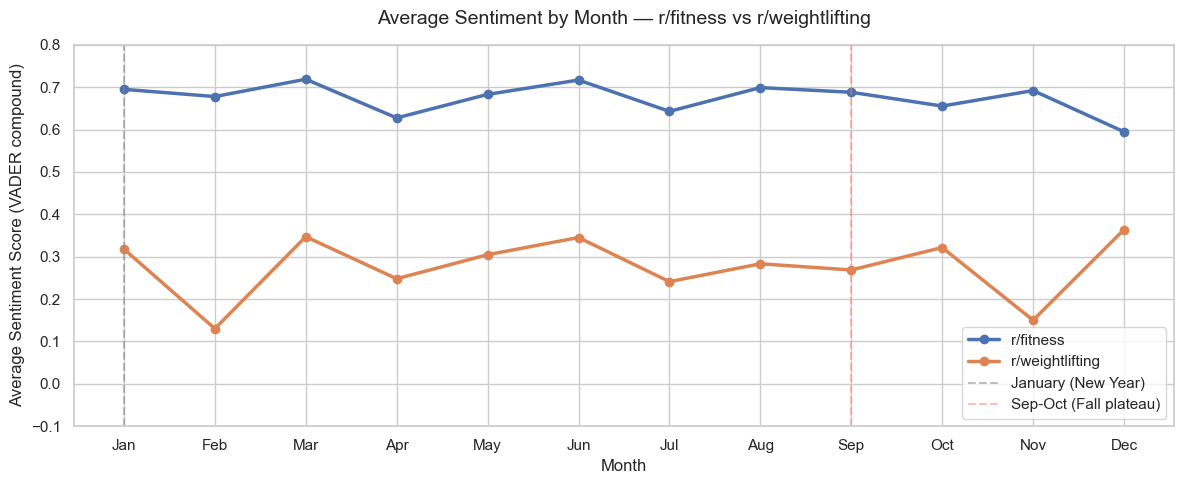

Chart 1 saved.


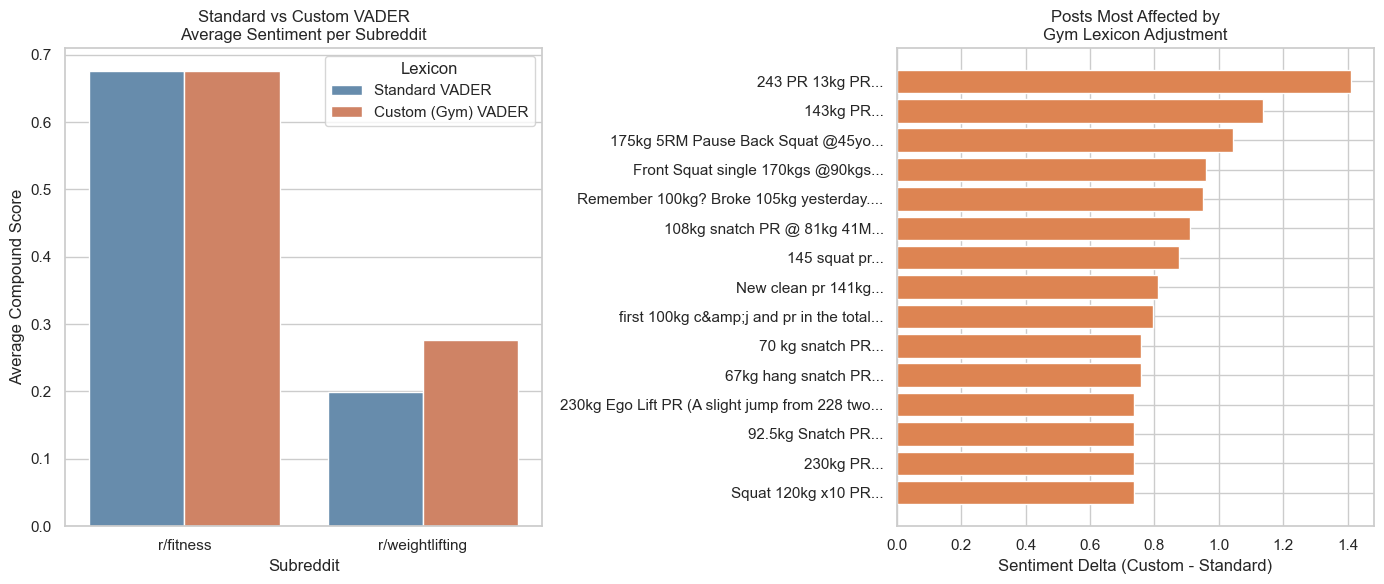

Chart 2 saved.


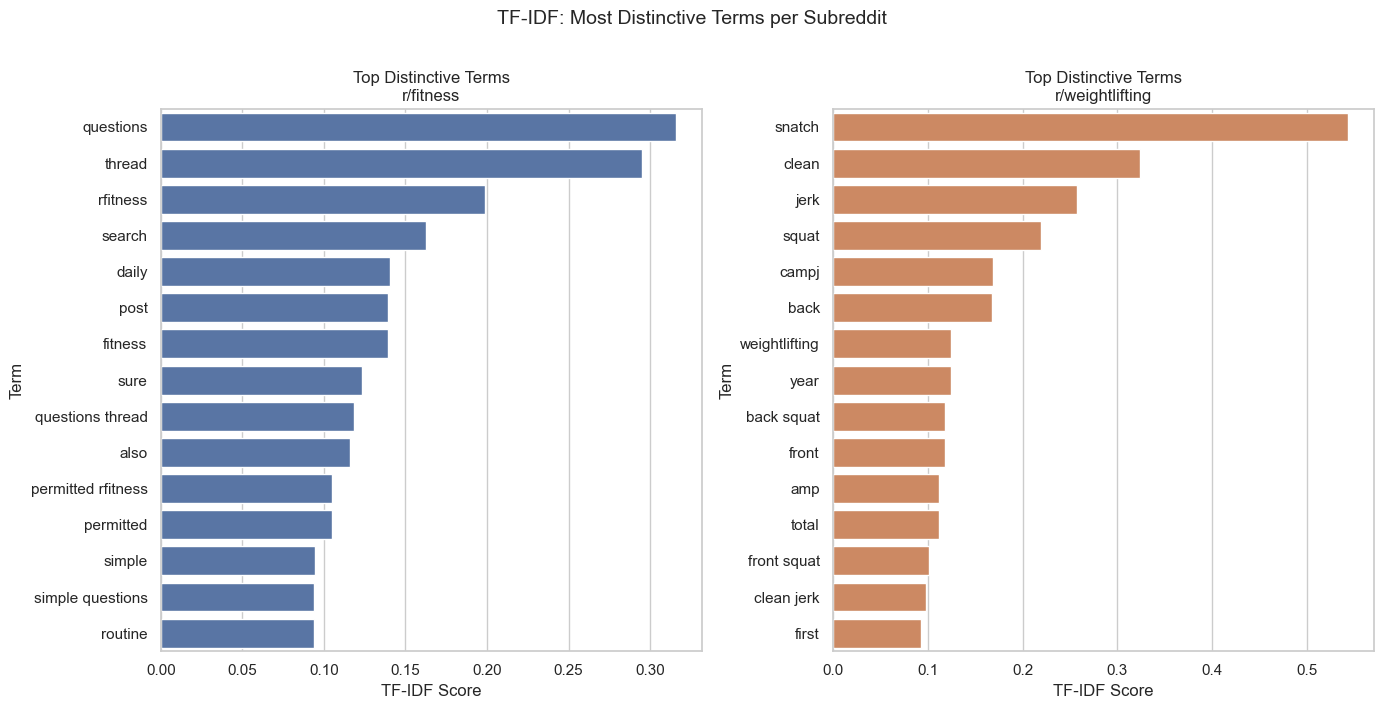

Chart 3 saved.


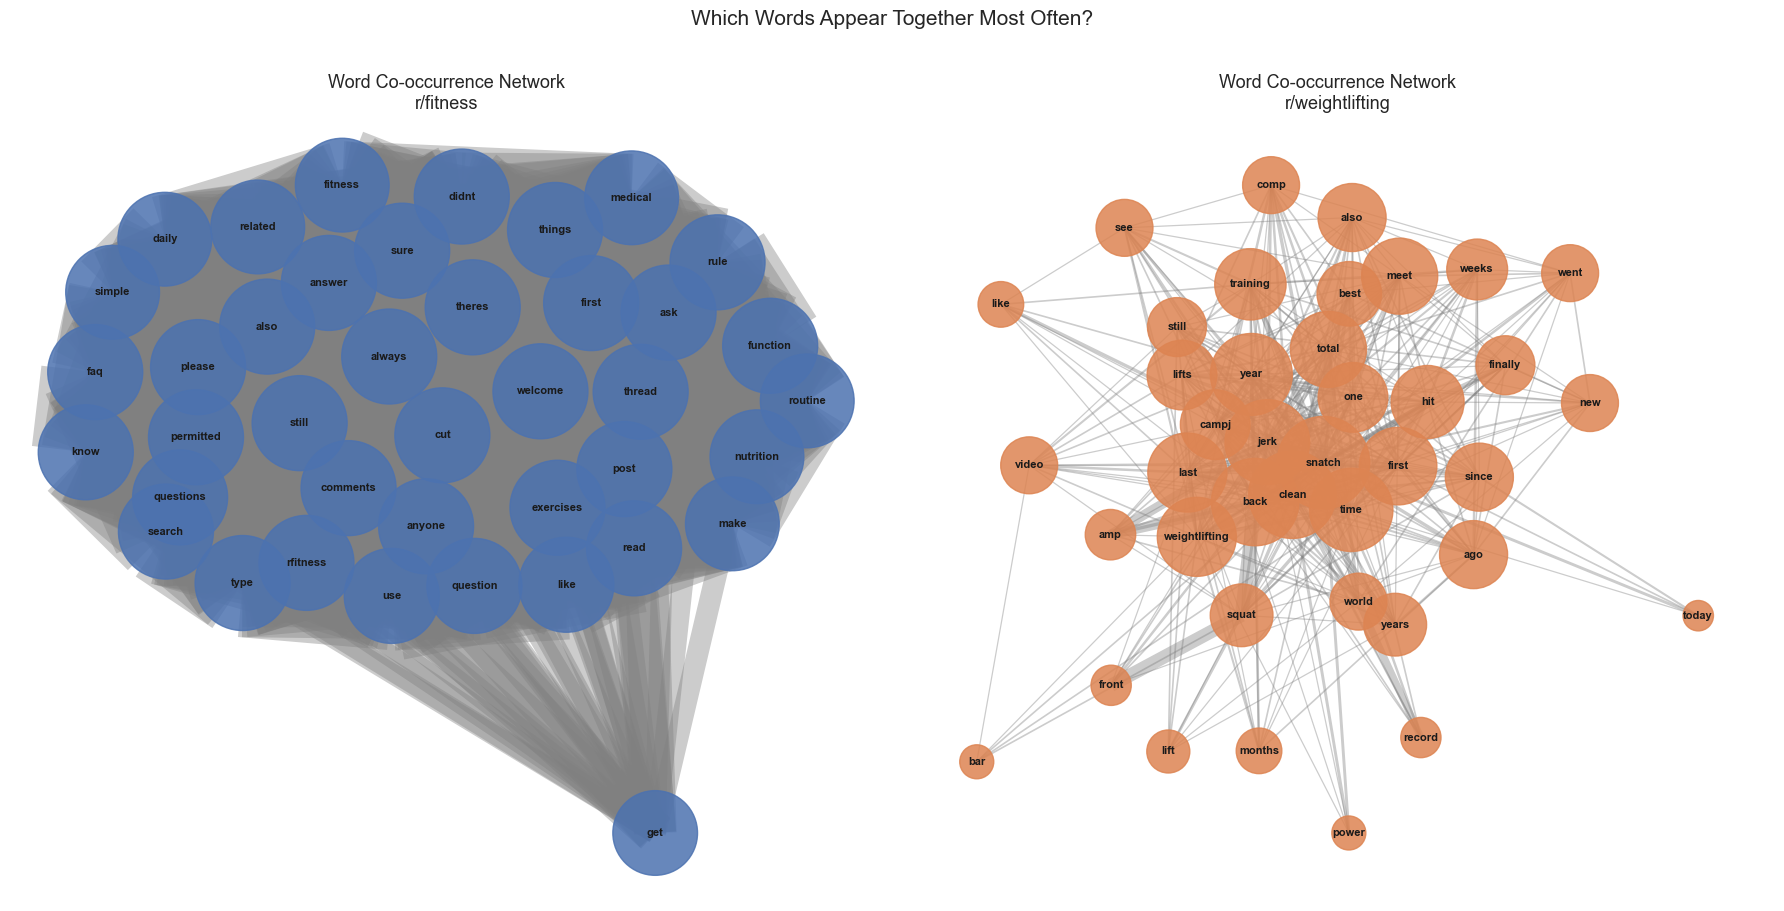

Chart 4 saved.
All charts complete and saved to the data/ folder.


In [3]:
#Part 3: Put code here
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import networkx as nx
from itertools import combinations
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR = 'data'

# Load processed data from Part 2
posts     = pd.read_pickle(f'{OUTPUT_DIR}/processed_posts.pkl')
top_terms = pd.read_pickle(f'{OUTPUT_DIR}/top_tfidf_terms.pkl')

sns.set_theme(style='whitegrid', palette='muted')
COLORS = {'fitness': '#4C72B0', 'weightlifting': '#DD8452'}

# ─────────────────────────────────────────────
# Chart 1: Seasonal Sentiment — Line Chart
# Research question: Does positive sentiment spike in January?
# ─────────────────────────────────────────────
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

seasonal = (
    posts.groupby(['subreddit', 'month_name'])['sentiment_custom']
    .mean()
    .reset_index()
)
seasonal['month_name'] = pd.Categorical(seasonal['month_name'], categories=month_order, ordered=True)
seasonal = seasonal.sort_values('month_name')

fig, ax = plt.subplots(figsize=(12, 5))

for sub, group in seasonal.groupby('subreddit'):
    ax.plot(group['month_name'], group['sentiment_custom'],
            marker='o', linewidth=2.5, label=f'r/{sub}', color=COLORS[sub])

ax.axvline(x='Jan', color='gray', linestyle='--', alpha=0.5, label='January (New Year)')
ax.axvline(x='Sep', color='salmon', linestyle='--', alpha=0.5, label='Sep-Oct (Fall plateau)')
ax.set_title('Average Sentiment by Month — r/fitness vs r/weightlifting', fontsize=14, pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Average Sentiment Score (VADER compound)')
ax.legend()
ax.set_ylim(-0.1, 0.8)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart1_seasonal_sentiment.png', dpi=150)
plt.show()
print('Chart 1 saved.')

# ─────────────────────────────────────────────
# Chart 2: Gym Talk Inversion — Bar Chart
# Research question: How much does the custom lexicon change sentiment scores?
# ─────────────────────────────────────────────

# Find posts where the lexicon made the biggest difference
top_delta = (
    posts[posts['sentiment_delta'] > 0]
    .nlargest(15, 'sentiment_delta')
    [['title', 'subreddit', 'sentiment_standard', 'sentiment_custom', 'sentiment_delta']]
    .copy()
)
top_delta['short_title'] = top_delta['title'].str[:45] + '...'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: overall average comparison
avg_sentiment = posts.groupby('subreddit')[['sentiment_standard', 'sentiment_custom']].mean().reset_index()
avg_melted = avg_sentiment.melt(id_vars='subreddit', var_name='Lexicon', value_name='Average Sentiment')
avg_melted['Lexicon'] = avg_melted['Lexicon'].map({
    'sentiment_standard': 'Standard VADER',
    'sentiment_custom': 'Custom (Gym) VADER'
})

sns.barplot(data=avg_melted, x='subreddit', y='Average Sentiment',
            hue='Lexicon', ax=axes[0], palette=['#5B8DB8', '#E07B54'])
axes[0].set_title('Standard vs Custom VADER\nAverage Sentiment per Subreddit', fontsize=12)
axes[0].set_xlabel('Subreddit')
axes[0].set_ylabel('Average Compound Score')
axes[0].set_xticklabels(['r/fitness', 'r/weightlifting'])

# Right: top posts most affected by the gym lexicon
axes[1].barh(top_delta['short_title'], top_delta['sentiment_delta'],
             color=[COLORS[s] for s in top_delta['subreddit']])
axes[1].set_title('Posts Most Affected by\nGym Lexicon Adjustment', fontsize=12)
axes[1].set_xlabel('Sentiment Delta (Custom - Standard)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart2_gym_talk_inversion.png', dpi=150)
plt.show()
print('Chart 2 saved.')

# ─────────────────────────────────────────────
# Chart 3: TF-IDF Technical Density — Bar Chart
# Research question: Does r/weightlifting use more technical jargon?
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, sub in zip(axes, ['fitness', 'weightlifting']):
    data = top_terms[top_terms['subreddit'] == sub].head(15)
    sns.barplot(data=data, x='score', y='term', ax=ax, color=COLORS[sub])
    ax.set_title(f'Top Distinctive Terms\nr/{sub}', fontsize=12)
    ax.set_xlabel('TF-IDF Score')
    ax.set_ylabel('Term')

plt.suptitle('TF-IDF: Most Distinctive Terms per Subreddit', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart3_tfidf_density.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3 saved.')

# ─────────────────────────────────────────────
# Chart 4: Word Co-occurrence Network — NetworkX
# Shows which words appear together most often in each subreddit
# ─────────────────────────────────────────────
def build_cooccurrence_graph(texts, top_n_words=40, min_edge_weight=3):
    """Build a word co-occurrence graph from a list of cleaned texts."""
    # Get the most common words to use as nodes
    all_words = ' '.join(texts).split()
    common_words = {w for w, _ in Counter(all_words).most_common(top_n_words)}

    # Count how often pairs of words appear in the same post
    edge_counts = Counter()
    for text in texts:
        words = [w for w in text.split() if w in common_words]
        for pair in combinations(set(words), 2):
            edge_counts[tuple(sorted(pair))] += 1

    # Build graph — only include edges that appear together enough times
    G = nx.Graph()
    for (w1, w2), weight in edge_counts.items():
        if weight >= min_edge_weight:
            G.add_edge(w1, w2, weight=weight)

    return G

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

for ax, sub in zip(axes, ['fitness', 'weightlifting']):
    texts = posts[posts['subreddit'] == sub]['clean_text'].dropna().tolist()
    G = build_cooccurrence_graph(texts, top_n_words=40, min_edge_weight=3)

    if len(G.nodes) == 0:
        ax.text(0.5, 0.5, 'Not enough data', ha='center', va='center')
        continue

    # Node size based on how many connections it has
    node_sizes  = [G.degree(n) * 120 for n in G.nodes]
    # Edge thickness based on co-occurrence count
    edge_weights = [G[u][v]['weight'] * 0.3 for u, v in G.edges]

    pos = nx.spring_layout(G, seed=42, k=0.6)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes,
                           node_color=COLORS[sub], alpha=0.85)
    nx.draw_networkx_edges(G, pos, ax=ax, width=edge_weights, alpha=0.4, edge_color='gray')
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_weight='bold')

    ax.set_title(f'Word Co-occurrence Network\nr/{sub}', fontsize=13)
    ax.axis('off')

plt.suptitle('Which Words Appear Together Most Often?', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart4_cooccurrence_network.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 4 saved.')

print('All charts complete and saved to the data/ folder.')


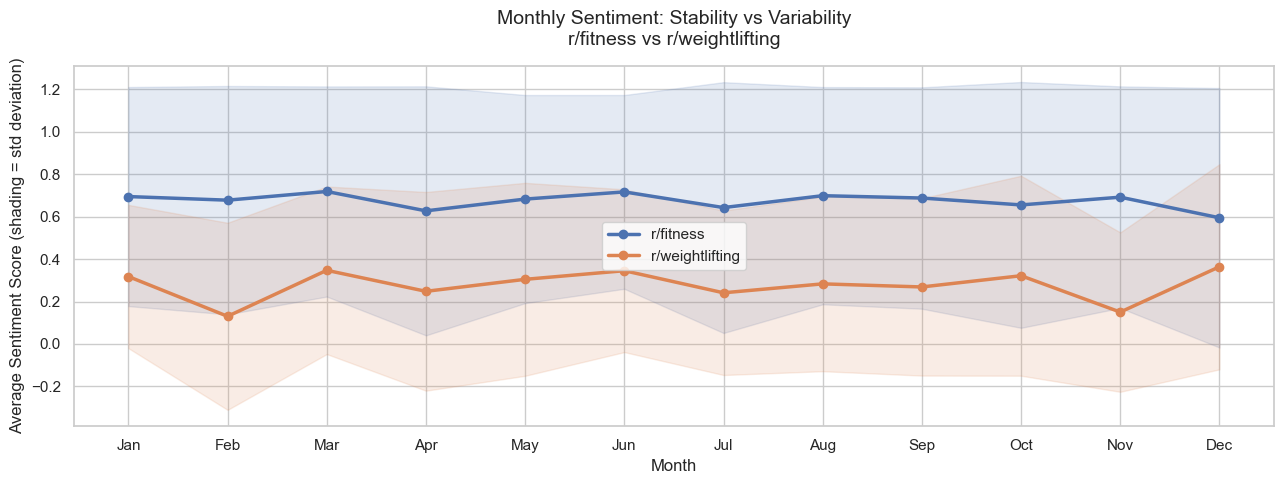

Chart 1b saved.


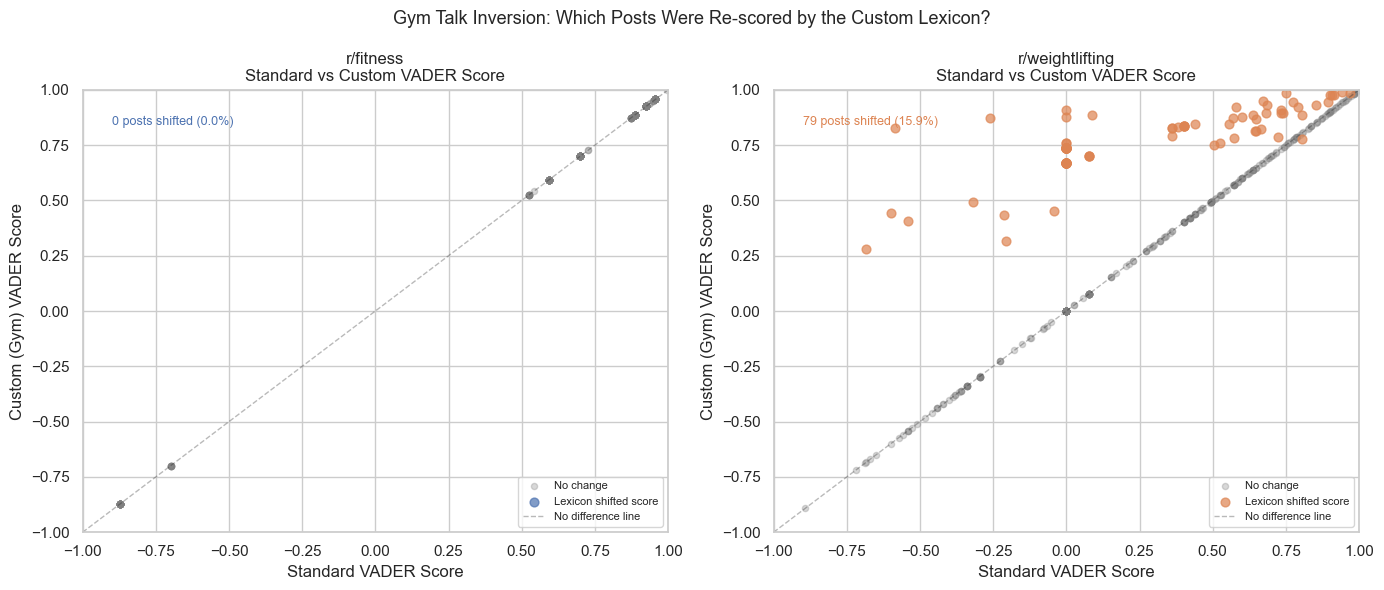

Chart 2b saved.


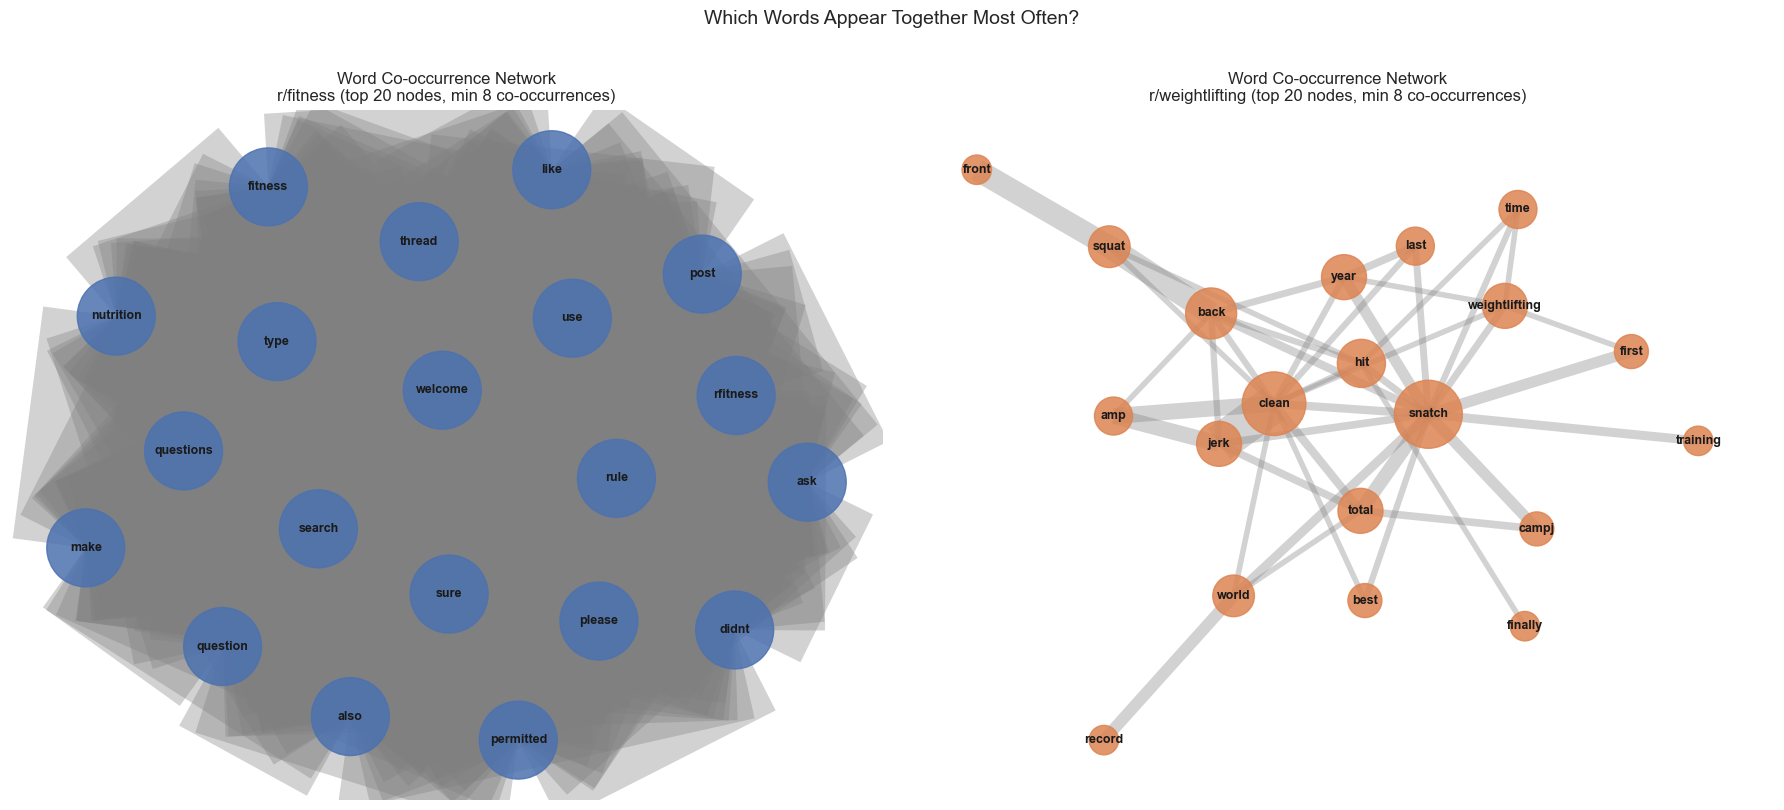

Chart 4b saved.
All improved charts complete and saved to the data/ folder.


In [5]:
OUTPUT_DIR = 'data'
posts     = pd.read_pickle(f'{OUTPUT_DIR}/processed_posts.pkl')
top_terms = pd.read_pickle(f'{OUTPUT_DIR}/top_tfidf_terms.pkl')

sns.set_theme(style='whitegrid', palette='muted')
COLORS = {'fitness': '#4C72B0', 'weightlifting': '#DD8452'}

# ─────────────────────────────────────────────
# Chart 1b: Sentiment Variability by Month
# Reframed from 'looking for a spike' to 'comparing stability vs variability'
# r/fitness is consistently positive; r/weightlifting fluctuates more
# ─────────────────────────────────────────────
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

seasonal = (
    posts.groupby(['subreddit', 'month_name'])['sentiment_custom']
    .agg(['mean', 'std'])
    .reset_index()
)
seasonal['month_name'] = pd.Categorical(seasonal['month_name'], categories=month_order, ordered=True)
seasonal = seasonal.sort_values('month_name')

fig, ax = plt.subplots(figsize=(13, 5))

for sub, group in seasonal.groupby('subreddit'):
    ax.plot(group['month_name'], group['mean'],
            marker='o', linewidth=2.5, label=f'r/{sub}', color=COLORS[sub])
    # Shaded band shows standard deviation — wider = more variability
    ax.fill_between(group['month_name'],
                    group['mean'] - group['std'],
                    group['mean'] + group['std'],
                    alpha=0.15, color=COLORS[sub])

ax.set_title('Monthly Sentiment: Stability vs Variability\nr/fitness vs r/weightlifting', fontsize=14, pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Average Sentiment Score (shading = std deviation)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart1b_seasonal_variability.png', dpi=150)
plt.show()
print('Chart 1b saved.')

# ─────────────────────────────────────────────
# Chart 2b: Gym Talk Inversion — Scatter Plot
# Shows standard vs custom score per post — posts that shifted are visible
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, sub in zip(axes, ['fitness', 'weightlifting']):
    data = posts[posts['subreddit'] == sub].copy()

    # Color by whether the gym lexicon changed the score
    changed = data['sentiment_delta'].abs() > 0.01
    ax.scatter(data.loc[~changed, 'sentiment_standard'],
               data.loc[~changed, 'sentiment_custom'],
               alpha=0.3, s=20, color='gray', label='No change')
    ax.scatter(data.loc[changed, 'sentiment_standard'],
               data.loc[changed, 'sentiment_custom'],
               alpha=0.7, s=40, color=COLORS[sub], label='Lexicon shifted score')

    # Diagonal line — points above it were scored higher by custom VADER
    ax.plot([-1, 1], [-1, 1], 'k--', alpha=0.3, linewidth=1, label='No difference line')
    ax.set_title(f'r/{sub}\nStandard vs Custom VADER Score', fontsize=12)
    ax.set_xlabel('Standard VADER Score')
    ax.set_ylabel('Custom (Gym) VADER Score')
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.legend(fontsize=8)

    n_changed = changed.sum()
    ax.text(0.05, 0.92, f'{n_changed} posts shifted ({100*n_changed/len(data):.1f}%)',
            transform=ax.transAxes, fontsize=9, color=COLORS[sub])

plt.suptitle('Gym Talk Inversion: Which Posts Were Re-scored by the Custom Lexicon?', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart2b_inversion_scatter.png', dpi=150)
plt.show()
print('Chart 2b saved.')

# ─────────────────────────────────────────────
# Chart 4b: Cleaner Co-occurrence Network
# Fewer nodes, higher edge threshold, only top connected nodes shown
# ─────────────────────────────────────────────
def build_clean_graph(texts, top_n_words=25, min_edge_weight=8):
    """Build a cleaner co-occurrence graph with stricter filtering."""
    all_words = ' '.join(texts).split()
    common_words = {w for w, _ in Counter(all_words).most_common(top_n_words)}

    edge_counts = Counter()
    for text in texts:
        words = [w for w in text.split() if w in common_words]
        for pair in combinations(set(words), 2):
            edge_counts[tuple(sorted(pair))] += 1

    G = nx.Graph()
    for (w1, w2), weight in edge_counts.items():
        if weight >= min_edge_weight:
            G.add_edge(w1, w2, weight=weight)

    # Keep only the most connected nodes to reduce clutter
    if len(G.nodes) > 0:
        top_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:20]
        G = G.subgraph([n for n, _ in top_nodes]).copy()

    return G

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, sub in zip(axes, ['fitness', 'weightlifting']):
    texts = posts[posts['subreddit'] == sub]['clean_text'].dropna().tolist()
    G = build_clean_graph(texts, top_n_words=25, min_edge_weight=8)

    if len(G.nodes) == 0:
        ax.text(0.5, 0.5, 'Not enough data', ha='center', va='center')
        ax.axis('off')
        continue

    node_sizes   = [300 + G.degree(n) * 150 for n in G.nodes]
    edge_weights = [G[u][v]['weight'] * 0.5 for u, v in G.edges]

    pos = nx.spring_layout(G, seed=42, k=1.2)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes,
                           node_color=COLORS[sub], alpha=0.85)
    nx.draw_networkx_edges(G, pos, ax=ax, width=edge_weights, alpha=0.35, edge_color='gray')
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_weight='bold')

    ax.set_title(f'Word Co-occurrence Network\nr/{sub} (top 20 nodes, min 8 co-occurrences)', fontsize=12)
    ax.axis('off')

plt.suptitle('Which Words Appear Together Most Often?', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart4b_clean_network.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 4b saved.')

print('All improved charts complete and saved to the data/ folder.')